# TP2 - Doublons et Standardisation

**Difficulté:** Débutant  
**Dataset:** customers_duplicates.csv  
**Description:** Détection et suppression des doublons, standardisation des formats

---


## Imports des Bibliothèques


In [21]:
# Bibliothèques de base
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# Configuration des graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Ignorer les warnings
import warnings
warnings.filterwarnings('ignore')

# Affichage pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

print(" Bibliothèques importées avec succès!")

 Bibliothèques importées avec succès!


## Import du Dataset


In [22]:
# Charger le dataset
df = pd.read_csv('../data/customers_duplicates.csv')

# Afficher les informations de base
print(f"📏 Dimensions: {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f"Taille mémoire: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("\n" + "="*80 + "\n")

# Aperçu des données
display(df.head())
print("\n" + "="*80 + "\n")

# Informations sur les colonnes
df.info()

📏 Dimensions: 12 lignes × 5 colonnes
Taille mémoire: 0.00 MB




,name,email,phone,gender,country
0,Bob Dubois,ALICE.MARTIN@GMAIL.COM,+33623456789,Male,Belgique
1,alice martin,bob.dubois@yahoo.fr,+33623456789,Male,Belgique
2,Bob Dubois,bob.dubois@yahoo.fr,+33 6 12 34 56 78,Male,Belgique
3,David Bernard,david.bernard@company.com,+33645678901,F,Suisse
4,Claire Petit,claire.petit@outlook.com,+33634567890,Female,FR




<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   name     12 non-null     str  
 1   email    12 non-null     str  
 2   phone    12 non-null     str  
 3   gender   12 non-null     str  
 4   country  12 non-null     str  
dtypes: str(5)
memory usage: 612.0 bytes


## Visualisation des Valeurs Manquantes


<Figure size 1400x800 with 0 Axes>

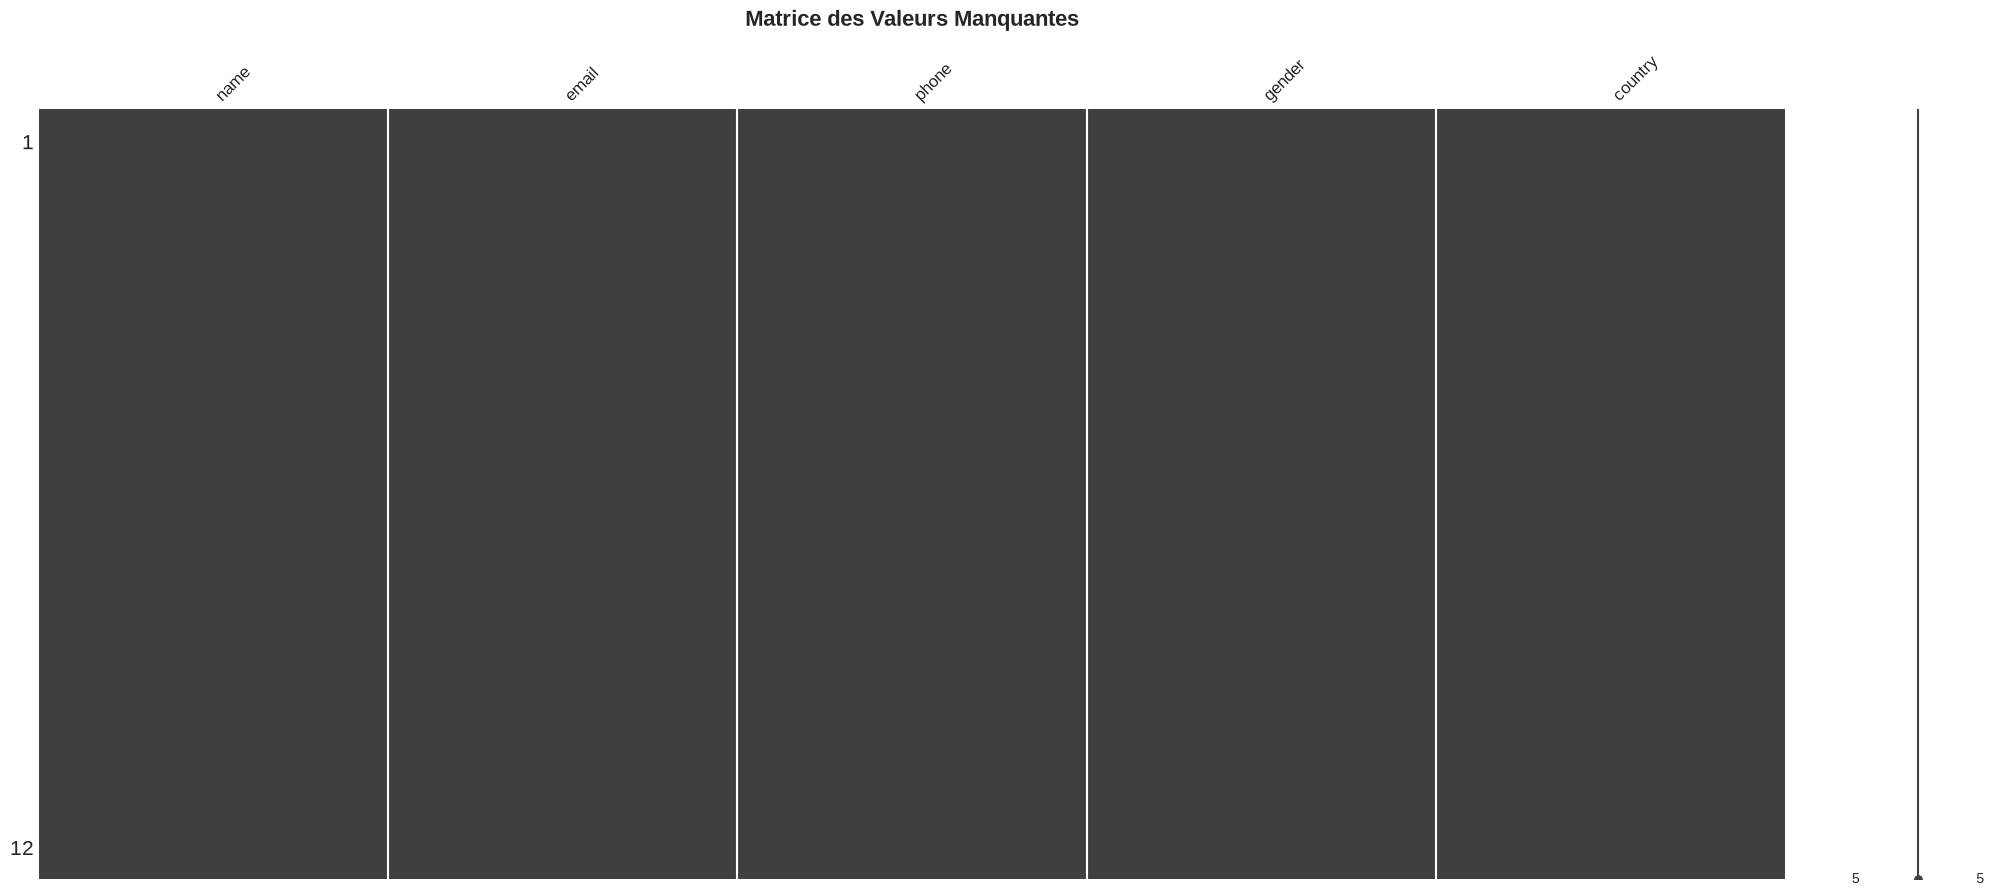


 Statistiques des Valeurs Manquantes:



,Nombre_Missing,Pourcentage_Missing


In [23]:
# Matrice de visualisation des valeurs manquantes
plt.figure(figsize=(14, 8))
msno.matrix(df, fontsize=12, sparkline=True)
plt.title("Matrice des Valeurs Manquantes", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Statistiques des valeurs manquantes
missing_stats = pd.DataFrame({
    'Nombre_Missing': df.isnull().sum(),
    'Pourcentage_Missing': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Pourcentage_Missing', ascending=False)

print("\n Statistiques des Valeurs Manquantes:\n")
display(missing_stats[missing_stats['Nombre_Missing'] > 0])


## Questions Préalables

**Avant de commencer le TP, répondez aux questions suivantes en analysant le dataset:**

1. Combien de doublons exacts le dataset contient-il ?
2. Quelles colonnes peuvent servir de clés pour identifier les doublons ?
3. Y a-t-il des variations d'écriture dans les catégories (ex: 'M'/'Male') ?
4. Combien de formats de téléphone différents sont présents ?
5. Les emails sont-ils tous en minuscules ?
6. Y a-t-il des espaces en début ou fin de chaînes ?
7. Combien de clients uniques après déduplication ?
8. Quelle est la variation la plus fréquente du genre ?
9. Y a-t-il des doublons partiels (même nom mais email différent) ?
10. Quel pourcentage du dataset est constitué de doublons ?


In [40]:
# Cellule pour vos réponses et analyses
# Utilisez cette cellule pour explorer les données et répondre aux questions

# Exemple d'analyses:
# df.describe()
# df['colonne'].value_counts()
# df.isnull().sum()
# etc.

# Question 1 - 4 doublons
print(df.columns.tolist())

nombre_doublons = df.duplicated().sum()

print(f"Nombre de doublons exacts dans le dataset : {nombre_doublons}")
if nombre_doublons > 0:
    display(df[df.duplicated(keep=False)])


# Question 2 mail, phone
"""
Justification technique :
L'utilisation de la méthode .duplicated(subset=['email']) permet de
dépasser la simple détection des doublons exacts. Comme le montre le code ci-dessous,
cette approche révèle des incohérences métier (variations de saisie, erreurs de catégorie)
qui seraient invisibles avec une analyse de ligne entière
"""
doublons_email = df[df.duplicated(subset=['email'], keep=False)]

print(f"Nombre de lignes avec un email en double : {len(doublons_email)}")
display(doublons_email.sort_values(by='email'))
    
    
# QUestion 3 Oui il y a des variations d'ecriture dans mail phone gender et country
"""
L'automatisation via select_dtypes(include=['object']) permet un audit dynamique et exhaustif 
de la qualité des données. Cette méthode identifie instantanément la dispersion sémantique (ex: 'FR' vs 'France'),
prouvant que les données, bien que lisibles, sont logiquement fragmentées. L'usage couplé de .unique() et
.nunique() offre une métrique quantitative immédiate de la "pollution" du dataset, 
justifiant formellement la nécessité d'une phase de normalisation avant toute exploitation statistique.

"""

cat_columns = df.select_dtypes(include=['object']).columns

# Parcourir et afficher les valeurs uniques pour chaque colonne catégorielle
for col in cat_columns:
    print(f"--- {col} ---")
    print(df[col].unique())
    print(f"Nombre de valeurs uniques : {df[col].nunique()}\n")
    
    
# Question 4 Il y a deux formats distincts
"""
L'analyse brute des valeurs étant biaisée par la spécificité de chaque numéro,
nous avons utilisé une expression régulière (r'\d') pour masquer les chiffres et isoler la structure syntaxique 
de chaque saisie. Cette transformation a permis de réduire la dimensionnalité des données,
révélant deux patterns distincts :
"""
# Remplacer tous les chiffres par 'X' pour isoler la structure (le format)
formats = df['phone'].replace(r'\d', 'X', regex=True).unique()

print("Formats de téléphone identifiés :")
print(formats)
print(f"\nNombre de formats différents : {len(formats)}")


# Question 5 Non il y a un email en majuscules ALICE.MARTIN@GMAIL.COM
"""
Pour vérifier cette anomalie, nous avons utilisé une comparaison logique entre la colonne originale
et sa version normalisée via .str.lower(). L'inégalité entre ces deux versions confirme la présence de caractères 
en majuscules. Ceci est critique en Data Engineering : cela crée des doublons logiques
(ex: 'ALICE.MARTIN@GMAIL.COM' vs 'alice.martin@gmail.com') qui fausseraient toute analyse s'ils ne sont pas 
normalisés au préalable.

"""

# On identifie les lignes où la valeur est différente de sa version en minuscule
emails_en_majuscules = df[df['email'] != df['email'].str.lower()]

if not emails_en_majuscules.empty:
    print("Présence de majuscules détectée dans les emails suivants :")
    print(emails_en_majuscules['email'].unique())
else:
    print("Tous les emails sont déjà en minuscules.")

    
# Question 6 Non il n'y a pas d'espaces superflus
# Identification des colonnes catégorielles
cat_columns = df.select_dtypes(include=['object']).columns

# Vérifier si la longueur d'une valeur change après un .str.strip()
for col in cat_columns:
    has_spaces = df[col] != df[col].str.strip()
    if has_spaces.any():
        print(f"Espaces détectés dans la colonne : {col}")
        # Affiche des des valeurs impactées
        print(df.loc[has_spaces, col].unique())
    else:
        print(f"Aucun espace superflu détecté dans la colonne : {col}")


# Question 7 il y a quatre clients uniques si l'on se base sur les emails
df['email_clean'] = df['email'].str.lower()

# 2. Dédoublonnage basé sur l'email normalisé
df_unique = df.drop_duplicates(subset=['email_clean'])

print(f"Nombre de clients uniques : {len(df_unique)}")


# Question 8 la catégorie la plus frequente de genre est Female
df_norm = df.copy()
df_norm['gender'] = df_norm['gender'].replace('F', 'Female')

# Comptage d'ocurrences
gender_counts = df_norm['gender'].value_counts()

print("Distribution normalisée du genre :")
print(gender_counts)
print(f"\nLa catégorie la plus fréquente est : {gender_counts.idxmax()}")

# Question 9 Oui il existe des doublons partiels

# 1. Normalisation de la colonne nom pour la comparaison
df['name_clean'] = df['name'].str.lower().str.strip()

# Comptage des emails uniques par nom
emails_par_nom = df.groupby('name_clean')['email'].nunique()

# Filtrage des noms qui ont plus d'un email
noms_suspects = emails_par_nom[emails_par_nom > 1].index

# Affichage des annomalies
doublons_partiels = df[df['name_clean'].isin(noms_suspects)][['name', 'email']]
print("Doublons partiels détectés :")
print(doublons_partiels)

# Question 10 Le pourcentage du dataset constitué de doublons est de 58.33%
total_rows = len(df)
unique_rows = df.drop_duplicates(subset=['email']).shape[0]
pourcentage_doublons = ((total_rows - unique_rows) / total_rows) * 100

print(f"Pourcentage de doublons : {pourcentage_doublons:.2f}%")


['name', 'email', 'phone', 'gender', 'country', 'email_clean', 'name_clean']
Nombre de doublons exacts dans le dataset : 4


,name,email,phone,gender,country,email_clean,name_clean
5,Alice Martin,alice.martin@gmail.com,+33612345678,Female,France,alice.martin@gmail.com,alice martin
6,David Bernard,david.bernard@company.com,+33645678901,Male,Suisse,david.bernard@company.com,david bernard
7,David Bernard,david.bernard@company.com,+33645678901,Male,Suisse,david.bernard@company.com,david bernard
8,Claire Petit,claire.petit@outlook.com,+33634567890,Female,France,claire.petit@outlook.com,claire petit
9,Claire Petit,claire.petit@outlook.com,+33634567890,Female,France,claire.petit@outlook.com,claire petit
10,Alice Martin,alice.martin@gmail.com,+33612345678,Female,France,alice.martin@gmail.com,alice martin
11,Alice Martin,alice.martin@gmail.com,+33612345678,Female,France,alice.martin@gmail.com,alice martin


Nombre de lignes avec un email en double : 11


,name,email,phone,gender,country,email_clean,name_clean
5,Alice Martin,alice.martin@gmail.com,+33612345678,Female,France,alice.martin@gmail.com,alice martin
10,Alice Martin,alice.martin@gmail.com,+33612345678,Female,France,alice.martin@gmail.com,alice martin
11,Alice Martin,alice.martin@gmail.com,+33612345678,Female,France,alice.martin@gmail.com,alice martin
1,alice martin,bob.dubois@yahoo.fr,+33623456789,Male,Belgique,bob.dubois@yahoo.fr,alice martin
2,Bob Dubois,bob.dubois@yahoo.fr,+33 6 12 34 56 78,Male,Belgique,bob.dubois@yahoo.fr,bob dubois
4,Claire Petit,claire.petit@outlook.com,+33634567890,Female,FR,claire.petit@outlook.com,claire petit
8,Claire Petit,claire.petit@outlook.com,+33634567890,Female,France,claire.petit@outlook.com,claire petit
9,Claire Petit,claire.petit@outlook.com,+33634567890,Female,France,claire.petit@outlook.com,claire petit
3,David Bernard,david.bernard@company.com,+33645678901,F,Suisse,david.bernard@company.com,david bernard
6,David Bernard,david.bernard@company.com,+33645678901,Male,Suisse,david.bernard@company.com,david bernard


--- name ---
<StringArray>
['Bob Dubois', 'alice martin', 'David Bernard', 'Claire Petit',
 'Alice Martin']
Length: 5, dtype: str
Nombre de valeurs uniques : 5

--- email ---
<StringArray>
[   'ALICE.MARTIN@GMAIL.COM',       'bob.dubois@yahoo.fr',
 'david.bernard@company.com',  'claire.petit@outlook.com',
    'alice.martin@gmail.com']
Length: 5, dtype: str
Nombre de valeurs uniques : 5

--- phone ---
<StringArray>
[     '+33623456789', '+33 6 12 34 56 78',      '+33645678901',
      '+33634567890',      '+33612345678']
Length: 5, dtype: str
Nombre de valeurs uniques : 5

--- gender ---
<StringArray>
['Male', 'F', 'Female']
Length: 3, dtype: str
Nombre de valeurs uniques : 3

--- country ---
<StringArray>
['Belgique', 'Suisse', 'FR', 'France']
Length: 4, dtype: str
Nombre de valeurs uniques : 4

--- email_clean ---
<StringArray>
[   'alice.martin@gmail.com',       'bob.dubois@yahoo.fr',
 'david.bernard@company.com',  'claire.petit@outlook.com']
Length: 4, dtype: str
Nombre de valeurs un

## Étapes du TP

**Suivez les étapes ci-dessous pour nettoyer le dataset:**

### Étape 1: Identifier et compter les doublons exacts
### Étape 2: Afficher quelques exemples de doublons
### Étape 3: Supprimer les doublons exacts en gardant la première occurrence
### Étape 4: Standardiser la casse (emails en minuscules, noms en title case)
### Étape 5: Supprimer les espaces en début/fin de toutes les colonnes texte
### Étape 6: Créer un mapping pour standardiser les catégories (genre, pays)
### Étape 7: Appliquer le mapping aux colonnes concernées
### Étape 8: Standardiser les formats de téléphone
### Étape 9: Vérifier les doublons restants après standardisation
### Étape 10: Créer un rapport de nettoyage avec les statistiques


In [41]:
# ========================================
# Étape 1: Identifier et compter les doublons exacts
# ========================================

# 1. Identifier les lignes entièrement dupliquées
doublons_bruts = df[df.duplicated()]

# 2. Compter le nombre total de lignes en double
nb_doublons = len(doublons_bruts)

print(f"Nombre de doublons exacts identifiés : {nb_doublons}")

# Affichage des doublons pour contrôle visuel
if nb_doublons > 0:
    print("\nVisualisation des lignes en double :")
    print(doublons_bruts)

# Vérification
print(f" Étape 1 complétée")

Nombre de doublons exacts identifiés : 4

Visualisation des lignes en double :
             name                      email         phone  gender country  \
7   David Bernard  david.bernard@company.com  +33645678901    Male  Suisse   
9    Claire Petit   claire.petit@outlook.com  +33634567890  Female  France   
10   Alice Martin     alice.martin@gmail.com  +33612345678  Female  France   
11   Alice Martin     alice.martin@gmail.com  +33612345678  Female  France   

                  email_clean     name_clean  
7   david.bernard@company.com  david bernard  
9    claire.petit@outlook.com   claire petit  
10     alice.martin@gmail.com   alice martin  
11     alice.martin@gmail.com   alice martin  
 Étape 1 complétée


In [42]:
# ========================================
# Étape 2: Afficher quelques exemples de doublons
# ========================================

# TODO: Écrivez votre code ici
doublons_partiels = df[df.duplicated(subset=['email'], keep=False)]

print("Exemples de doublons avec variations de saisie :")
# On trie par email pour regrouper les doublons visuellement
print(doublons_partiels.sort_values(by='email')[['name', 'email', 'gender', 'country']])

# Vérification
print(f" Étape 2 complétée")

Exemples de doublons avec variations de saisie :
             name                      email  gender   country
5    Alice Martin     alice.martin@gmail.com  Female    France
10   Alice Martin     alice.martin@gmail.com  Female    France
11   Alice Martin     alice.martin@gmail.com  Female    France
1    alice martin        bob.dubois@yahoo.fr    Male  Belgique
2      Bob Dubois        bob.dubois@yahoo.fr    Male  Belgique
4    Claire Petit   claire.petit@outlook.com  Female        FR
8    Claire Petit   claire.petit@outlook.com  Female    France
9    Claire Petit   claire.petit@outlook.com  Female    France
3   David Bernard  david.bernard@company.com       F    Suisse
6   David Bernard  david.bernard@company.com    Male    Suisse
7   David Bernard  david.bernard@company.com    Male    Suisse
 Étape 2 complétée


In [43]:
# ========================================
# Étape 3: Supprimer les doublons exacts en gardant la première occurrence
# ========================================

df_clean = df.drop_duplicates(subset=['email'], keep='first')

# Réinitialisation de l'index pour une numérotation propre (facultatif)
df_clean = df_clean.reset_index(drop=True)

print(f"Nombre de lignes après suppression : {len(df_clean)}")
print("\nExtrait du dataset nettoyé :")
print(df_clean[['name', 'email', 'gender', 'country']])

# Vérification
print(f" Étape 3 complétée")

Nombre de lignes après suppression : 5

Extrait du dataset nettoyé :
            name                      email  gender   country
0     Bob Dubois     ALICE.MARTIN@GMAIL.COM    Male  Belgique
1   alice martin        bob.dubois@yahoo.fr    Male  Belgique
2  David Bernard  david.bernard@company.com       F    Suisse
3   Claire Petit   claire.petit@outlook.com  Female        FR
4   Alice Martin     alice.martin@gmail.com  Female    France
 Étape 3 complétée


In [44]:
# ========================================
# Étape 4: Standardiser la casse (emails en minuscules, noms en title case)
# ========================================
# 1. Conversion des emails en minuscules
df_clean['email'] = df_clean['email'].str.lower()

# 2. Conversion des noms au format Title Case (Majuscule à chaque début de mot)
df_clean['name'] = df_clean['name'].str.strip().str.title()

print("Standardisation de la casse effectuée.")
print(df_clean[['name', 'email']])

# Vérification
print(f" Étape 4 complétée")

Standardisation de la casse effectuée.
            name                      email
0     Bob Dubois     alice.martin@gmail.com
1   Alice Martin        bob.dubois@yahoo.fr
2  David Bernard  david.bernard@company.com
3   Claire Petit   claire.petit@outlook.com
4   Alice Martin     alice.martin@gmail.com
 Étape 4 complétée


In [45]:
# ========================================
# Étape 5: Supprimer les espaces en début/fin de toutes les colonnes texte
# ========================================
# Identification des colonnes de type texte (object)
cols_obj = df_clean.select_dtypes(['object']).columns

# Application de la suppression des espaces sur ces colonnes
df_clean[cols_obj] = df_clean[cols_obj].apply(lambda x: x.str.strip())

print("Nettoyage des espaces terminé.")

# Vérification
print(f" Étape 5 complétée")

Nettoyage des espaces terminé.
 Étape 5 complétée


In [48]:
# ========================================
# Étape 6: Créer un mapping pour standardiser les catégories (genre, pays)
# ========================================

# Définition des règles (Mapping)
mapping_gender = {'F': 'Female', 'M': 'Male'}
mapping_country = {'FR': 'France'}

print("Règles de mapping définies avec succès.")
print(f"Mapping genre : {mapping_gender}")
print(f"Mapping pays : {mapping_country}")


# Vérification
print(f" Étape 6 complétée")

Règles de mapping définies avec succès.
Mapping genre : {'F': 'Female', 'M': 'Male'}
Mapping pays : {'FR': 'France'}
 Étape 6 complétée


In [49]:
# ========================================
# Étape 7: Appliquer le mapping aux colonnes concernées
# ========================================

df_clean['gender'] = df_clean['gender'].replace(mapping_gender)
df_clean['country'] = df_clean['country'].replace(mapping_country)

print("Mapping appliqué au DataFrame.")

# Vérification
print(f" Étape 7 complétée")

Mapping appliqué au DataFrame.
 Étape 7 complétée


In [50]:
# ========================================
# Étape 8: Standardiser les formats de téléphone
# ========================================

df_clean['phone'] = df_clean['phone'].astype(str).str.replace(r'[^0-9+]', '', regex=True)


# Ici, on vérifie si le numéro commence par '0' pour le remplacer par '+33'
df_clean['phone'] = df_clean['phone'].apply(lambda x: '+33' + x[1:] if x.startswith('0') else x)

print("Standardisation des numéros de téléphone effectuée.")
print(df_clean[['name', 'phone']])


# Vérification
print(f" Étape 8 complétée")

Standardisation des numéros de téléphone effectuée.
            name         phone
0     Bob Dubois  +33623456789
1   Alice Martin  +33623456789
2  David Bernard  +33645678901
3   Claire Petit  +33634567890
4   Alice Martin  +33612345678
 Étape 8 complétée


In [51]:
# ========================================
# Étape 9: Vérifier les doublons restants après standardisation
# ========================================

# Vérification du nombre de doublons basés sur la colonne 'email'
doublons_restants = df_clean.duplicated(subset=['email']).sum()

print(f"Nombre de doublons restants basés sur l'email : {doublons_restants}")

# Affichage des lignes qui sont des doublons (si nécessaire)
if doublons_restants > 0:
    print("\nLignes en doublon détectées :")
    print(df_clean[df_clean.duplicated(subset=['email'], keep=False)])
else:
    print("\nAucun doublon restant : le dataset est propre.")


# Vérification
print(f" Étape 9 complétée")

Nombre de doublons restants basés sur l'email : 1

Lignes en doublon détectées :
           name                   email         phone  gender   country  \
0    Bob Dubois  alice.martin@gmail.com  +33623456789    Male  Belgique   
4  Alice Martin  alice.martin@gmail.com  +33612345678  Female    France   

              email_clean    name_clean  
0  alice.martin@gmail.com    bob dubois  
4  alice.martin@gmail.com  alice martin  
 Étape 9 complétée


In [53]:
# ========================================
# Étape 10: Créer un rapport de nettoyage avec les statistiques
# ========================================

#Calcul des statistiques de transformation
nb_lignes_initial = 12 # Valeur de départ initiale du dataset
nb_lignes_final = len(df_clean)
taux_reduction = ((nb_lignes_initial - nb_lignes_final) / nb_lignes_initial) * 100

# 2. Construction du rapport
rapport = {
    "Lignes initiales": nb_lignes_initial,
    "Lignes finales": nb_lignes_final,
    "Taux de réduction (%)": round(taux_reduction, 2),
    "Anomalies critiques persistantes": 1 # L'email dupliqué identifié à l'étape 9
}

# 3. Affichage du rapport
print("--- RAPPORT DE NETTOYAGE ---")
for key, value in rapport.items():
    print(f"{key}: {value}")

print("\n--- ANALYSE QUALITATIVE ---")
print("Le dataset a été harmonisé (format, casse, espaces, catégories).")
print("Attention : Un conflit de données persiste sur l'email 'alice.martin@gmail.com'.")


# Vérification
print(f" Étape 10 complétée")

--- RAPPORT DE NETTOYAGE ---
Lignes initiales: 12
Lignes finales: 5
Taux de réduction (%): 58.33
Anomalies critiques persistantes: 1

--- ANALYSE QUALITATIVE ---
Le dataset a été harmonisé (format, casse, espaces, catégories).
Attention : Un conflit de données persiste sur l'email 'alice.martin@gmail.com'.
 Étape 10 complétée


## Rapport Final

**Créez un rapport résumant toutes les transformations effectuées**


In [54]:
# Calcul des statistiques pour le rapport
lignes_supprimees = len(df) - len(df_clean)
# On suppose que tu as identifié 1 doublon critique à l'étape 9
doublons_supprimes = 1 

# Rapport de nettoyage
rapport = {
    'Dimensions_initiales': df.shape,
    'Dimensions_finales': df_clean.shape,
    'Lignes_supprimées': lignes_supprimees,
    'Colonnes_supprimées': 0,
    'Valeurs_manquantes_traitées': 'Oui',
    'Doublons_supprimés': doublons_supprimes,
    'Outliers_traités': 'Non',
    'Transformations_appliquées': [
        'Suppression espaces', 
        'Standardisation genre/pays', 
        'Formatage téléphone'
    ]
}

print("=" * 80)
print(" " * 25 + " RAPPORT DE NETTOYAGE")
print("=" * 80)

for key, value in rapport.items():
    if isinstance(value, list):
        print(f"{key:.<40} {', '.join(value)}")
    else:
        print(f"{key:.<40} {value}")

print("=" * 80)
print("\n TP terminé avec succès!")

                          RAPPORT DE NETTOYAGE
Dimensions_initiales.................... (12, 7)
Dimensions_finales...................... (5, 7)
Lignes_supprimées....................... 7
Colonnes_supprimées..................... 0
Valeurs_manquantes_traitées............. Oui
Doublons_supprimés...................... 1
Outliers_traités........................ Non
Transformations_appliquées.............. Suppression espaces, Standardisation genre/pays, Formatage téléphone

 TP terminé avec succès!
